# Configuración

In [55]:
permitir_ejecuciones_costosas = False
num_jobs = -1

# Importar librerías

In [ ]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import tensorflow as tf

from typing import List, Optional, Tuple, Union

from matplotlib.colors import ListedColormap

from plotly.subplots import make_subplots
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder
)
from sklearn.metrics import (
    accuracy_score,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score,
    mean_squared_error, mean_absolute_error, r2_score
)

from lightgbm import LGBMClassifier

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

# Importar datos

In [57]:
PATH_DIRECTORIO_DATOS = "../../data"
PATH_DATASET_PRACTICA_FINAL = f"{PATH_DIRECTORIO_DATOS}/processed/dataset_practica_final_preprocessed.csv"

# Cargamos el dataset de la práctica final
df_preprocessed = pd.read_csv(PATH_DATASET_PRACTICA_FINAL)

In [58]:
# Definir variable objetivo
target_column = 'is_canceled'

# Diccionario de las categorías de la variable objetivo
dict_target_class_names = {
    0 : 'No cancelado',
    1 : 'Cancelado'
}

# Obtenemos la lista de nombres de las clases
list_target_class_names = dict_target_class_names.values()
list_target_class_names

dict_values(['No cancelado', 'Cancelado'])

In [59]:
# Definimos el índice de la clase cancelado
cancelado_idx = 1

In [60]:
df_preprocessed.shape

(119390, 46)

In [61]:
df_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 46 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   lead_time                       119390 non-null  float64
 1   stays_in_weekend_nights         119390 non-null  float64
 2   stays_in_week_nights            119390 non-null  float64
 3   adults                          119390 non-null  float64
 4   children                        119390 non-null  float64
 5   babies                          119390 non-null  float64
 6   is_repeated_guest               119390 non-null  float64
 7   previous_cancellations          119390 non-null  float64
 8   previous_bookings_not_canceled  119390 non-null  float64
 9   booking_changes                 119390 non-null  float64
 10  agent                           119390 non-null  float64
 11  company                         119390 non-null  float64
 12  adr             

In [62]:
# Contar valores nulos
df_preprocessed.isna().sum()

lead_time                         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
booking_changes                   0
agent                             0
company                           0
adr                               0
hotel_city hotel                  0
hotel_resort hotel                0
market_segment_aviation           0
market_segment_complementary      0
market_segment_corporate          0
market_segment_direct             0
market_segment_groups             0
market_segment_offline ta/to      0
market_segment_online ta          0
market_segment_undefined          0
distribution_channel_corporate    0
distribution_channel_direct       0
distribution_channel_gds          0
distribution_channel_ta/to        0
distribution_channel_undefin

In [63]:
# Verificar si hay valores duplicados en el dataframe
df_preprocessed.duplicated().sum()

38124

# Crear conjuntos de datos train y test

In [64]:
# Preparación de los datos para el modelo de regresión logística
# Eliminamos la columna 'target' de las variables independientes
# Y transformamos a numérico la columna target
# X = df_preprocessed.drop(columns=target)
X = df_preprocessed.drop(columns=target_column)
y = df_preprocessed[target_column]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [65]:
print(f"Recuento datos X_train: {len(X_train)}")
print(f"Recuento datos X_test:  {len(X_test)}")
print(f"Recuento datos y_train: {len(y_train)}")
print(f"Recuento datos y_test:  {len(y_test)}")

print(f"\nProporción de datos entre test y train:  {len(X_test) / (len(X_train) + len(X_test))}")

Recuento datos X_train: 95512
Recuento datos X_test:  23878
Recuento datos y_train: 95512
Recuento datos y_test:  23878

Proporción de datos entre test y train:  0.2


## Distribución de clases en variable target (``is_canceled``)

Verificaremos que el ratio de clases de la variable ``is_canceled`` en el dataset también se mantiene en:
- conjunto de entrenamiento
- conjunto de prueba

In [66]:
print("Distribución de clases en el dataset")
print(y.value_counts(normalize=True))

print("\nDistribución de clases en el conjunto de entrenamiento")
print(y_train.value_counts(normalize=True))

print("\nDistribución de clases en el conjunto de prueba")
print(y_test.value_counts(normalize=True))

Distribución de clases en el dataset
is_canceled
0    0.629584
1    0.370416
Name: proportion, dtype: float64

Distribución de clases en el conjunto de entrenamiento
is_canceled
0    0.630905
1    0.369095
Name: proportion, dtype: float64

Distribución de clases en el conjunto de prueba
is_canceled
0    0.624299
1    0.375701
Name: proportion, dtype: float64


In [67]:
# Se observa que el ratio difiere.
# Hacer train-test split utilizando stratify para que la proporción de clases se mantenga en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [68]:
print("Distribución de clases en el dataset")
print(y.value_counts(normalize=True))

print("\nDistribución de clases en el conjunto de entrenamiento")
print(y_train.value_counts(normalize=True))

print("\nDistribución de clases en el conjunto de prueba")
print(y_test.value_counts(normalize=True))

Distribución de clases en el dataset
is_canceled
0    0.629584
1    0.370416
Name: proportion, dtype: float64

Distribución de clases en el conjunto de entrenamiento
is_canceled
0    0.629586
1    0.370414
Name: proportion, dtype: float64

Distribución de clases en el conjunto de prueba
is_canceled
0    0.629575
1    0.370425
Name: proportion, dtype: float64


Conseguimos una distribución muy similar. Seguimos adelante.

# Modelo Regresión Logística (la línea base)
---

## Entrenamiento

In [69]:
%%time

# Entrenamos un modelo usando GridSearchCV para encontrar los mejores hiperparámetros
dict_parametros = {
    'C': [0.01, 0.1, 1],
    'max_iter' : [100, 200],
    'solver': ['liblinear']
}

modelo_lr = LogisticRegression(random_state=42)
modelo_lr_cv = GridSearchCV(modelo_lr, dict_parametros, cv=5, scoring='accuracy')
modelo_lr_cv.fit(X_train, y_train)

KeyboardInterrupt: 

In [ ]:
# Mostramos los mejores hiperparámetros encontrados
print(f"Mejores hiperparámetros encontrados: {modelo_lr_cv.best_params_}")
print(f"Mejor score obtenido: {modelo_lr_cv.best_score_:.2%}")

Mejores hiperparámetros encontrados: {'C': 1, 'max_iter': 100, 'solver': 'liblinear'}
Mejor score obtenido: 77.89%


In [ ]:
%%time

# Entrenamos el modelo con los mejores hiperparámetros encontrados
modelo_lr = LogisticRegression(
    C=modelo_lr_cv.best_params_['C'],
    max_iter=modelo_lr_cv.best_params_['max_iter'],
    solver=modelo_lr_cv.best_params_['solver'],
    random_state=42
)
modelo_lr.fit(X_train, y_train)

CPU times: total: 1.62 s
Wall time: 1.64 s


LogisticRegression(C=1, random_state=42, solver='liblinear')

---

## Evaluación



### Métrica elegida

Accuracy: mide cuántas predicciones de la clase positiva son correctas respecto al total.

In [ ]:
# Predecir sobre el conjunto de test
y_pred = modelo_lr.predict(X_test)

In [ ]:
len(y_pred)

23878

In [ ]:
# Obtenemos las probabilidades de pertenencia a la clase positiva (1)
# En este caso, la clase positiva es 'Cancelado'
y_proba = modelo_lr.predict_proba(X_test)[:, cancelado_idx]

In [ ]:
# Mostramos las primeras 5 etiquetas reales, las probabilidades de pertenencia a la clase positiva y las predicciones
print(f"Primeras 5 etiquetas reales: {y_test.iloc[:5].values}")
print(f"Primeras 5 probabilidades: {y_proba[:5]}")
print(f"Primeras 5 predicciones: {y_pred[:5]}")

Primeras 5 etiquetas reales: [0 0 1 0 0]
Primeras 5 probabilidades: [0.11520468 0.23271982 0.43686619 0.03984743 0.2326543 ]
Primeras 5 predicciones: [0 0 0 0 0]


In [ ]:
# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Cálculo del AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {acc:.2%}")
print(f"Precisión: {prec:.2%}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

Accuracy:  77.54%
Precisión: 88.00%
Recall:    0.46
F1-Score:  0.60
AUC:       0.82



In [ ]:
# Reporte detallado de las métricas de evaluación
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.75      0.96      0.84     15033
           1       0.88      0.46      0.60      8845

    accuracy                           0.78     23878
   macro avg       0.82      0.71      0.72     23878
weighted avg       0.80      0.78      0.75     23878



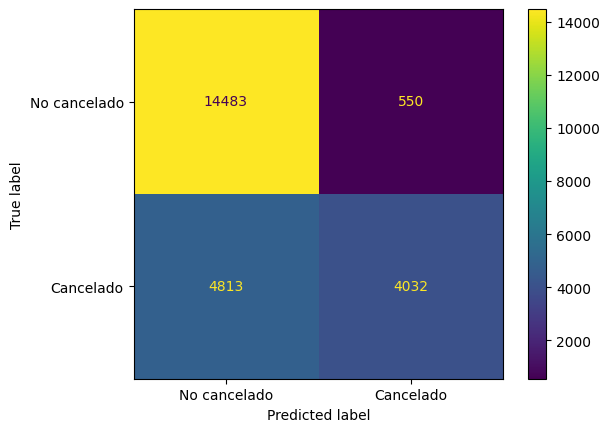

In [ ]:
# Mostrar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No cancelado', 'Cancelado'])
disp.plot(cmap='Blues')
plt.show()

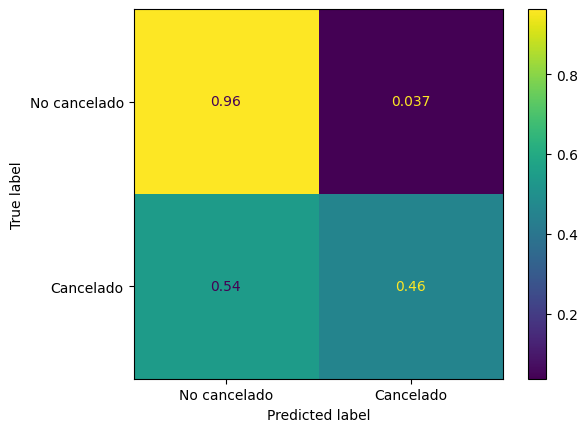

In [ ]:
# Mostrar la matriz de confusión normalizada
cm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No cancelado', 'Cancelado'])
disp.plot(cmap='Blues', values_format='.2%')
plt.show()

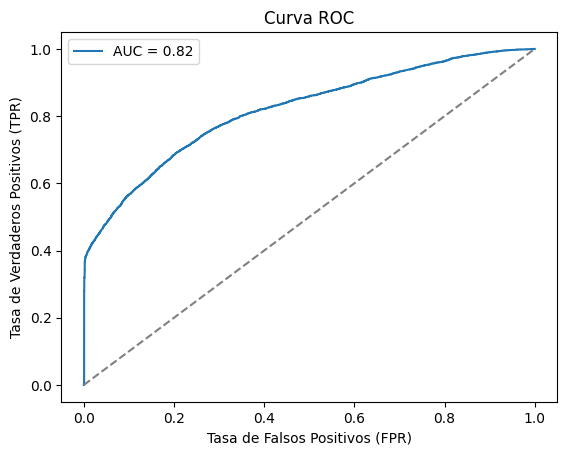

In [ ]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.show()

# Modelo Árbol de Decisión
---

In [ ]:
%%time

# Entrenamos un modelo de árbol de decisión
modelo_dt = DecisionTreeClassifier(max_depth=3, random_state=42)
modelo_dt.fit(X_train, y_train)

CPU times: total: 109 ms
Wall time: 101 ms


DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
# Hacemos predicciones sobre el conjunto de test
y_pred = modelo_dt.predict(X_test)

# Obtenemos las probabilidades de pertenencia a la clase positiva (1)
# En este caso, la clase positiva es 'Cancelado'
y_proba = modelo_dt.predict_proba(X_test)[:, cancelado_idx]

In [ ]:
# Verificamos cuántos elementos hay predichos
print(len(y_pred))

23878


In [ ]:
# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Cálculo del AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {acc:.2f}")
print(f"Precisión: {prec:.2f}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

Accuracy:  0.77
Precisión: 0.99
Recall:    0.37
F1-Score:  0.54
AUC:       0.74



In [ ]:
# Reporte detallado de las métricas de evaluación
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.73      1.00      0.84     15033
           1       0.99      0.37      0.54      8845

    accuracy                           0.77     23878
   macro avg       0.86      0.68      0.69     23878
weighted avg       0.82      0.77      0.73     23878



In [ ]:
if permitir_ejecuciones_costosas:
    # Visualizamos el árbol
    list_target_class_names =list(list_target_class_names)

    plt.figure(figsize=(10, 6))
    plot_tree(modelo_dt, feature_names=X.columns.to_list(), class_names=list_target_class_names, filled=True)
    plt.title("Árbol de decisión - Clasificación Predicción Cancelaciones Hotel")
    plt.show()

### Árbol de Decisión con GridSearch

In [ ]:
%%time

# Entrenamos un modelo usando GridSearchCV para encontrar los mejores hiperparámetros
dict_parametros = {
    'max_depth': [2, 3, 5, 10, 20, None],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4]
}

modelo_dt = DecisionTreeClassifier(random_state=42)
modelo_dt_cv = GridSearchCV(modelo_dt, dict_parametros, cv=5, scoring='accuracy')
modelo_dt_cv.fit(X_train, y_train)

CPU times: total: 2min 34s
Wall time: 2min 36s


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 3, 5, 10, 20, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='accuracy')

In [ ]:
# Visualizar los mejores hiperparámetros encontrados
print(f"Mejores hiperparámetros encontrados: {modelo_dt_cv.best_params_}")
print(f"Mejor score obtenido: {modelo_dt_cv.best_score_:.2%}")

Mejores hiperparámetros encontrados: {'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 4, 'min_samples_split': 20}
Mejor score obtenido: 79.47%


In [ ]:
# Entrenamos el modelo con los mejores hiperparámetros encontrados
modelo_dt = DecisionTreeClassifier(
    criterion=modelo_dt_cv.best_params_['criterion'],
    max_depth=modelo_dt_cv.best_params_['max_depth'],
    min_samples_leaf=modelo_dt_cv.best_params_['min_samples_leaf'],
    min_samples_split=modelo_dt_cv.best_params_['min_samples_split'],
    random_state=42
)
modelo_dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=20, min_samples_leaf=4, min_samples_split=20,
                       random_state=42)

In [ ]:
# Hacemos predicciones sobre el conjunto de test
y_pred = modelo_dt.predict(X_test)

# Obtenemos las probabilidades de pertenencia a la clase positiva (1)
# En este caso, la clase positiva es 'Cancelado'
y_proba = modelo_dt.predict_proba(X_test)[:, cancelado_idx]

# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Cálculo del AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {acc:.2f}")
print(f"Precisión: {prec:.2f}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

Accuracy:  0.80
Precisión: 0.77
Recall:    0.65
F1-Score:  0.70
AUC:       0.87



In [ ]:
# Reporte detallado de las métricas de evaluación
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85     15033
           1       0.77      0.65      0.70      8845

    accuracy                           0.80     23878
   macro avg       0.79      0.77      0.77     23878
weighted avg       0.80      0.80      0.79     23878



In [ ]:
if permitir_ejecuciones_costosas:
    # Visualizamos el árbol
    list_target_class_names =list(list_target_class_names)

    plt.figure(figsize=(10, 6))
    plot_tree(modelo_dt, feature_names=X.columns.to_list(), class_names=list_target_class_names, filled=True)
    plt.title("Árbol de decisión - Clasificación Predicción Cancelaciones Hotel")
    plt.show()

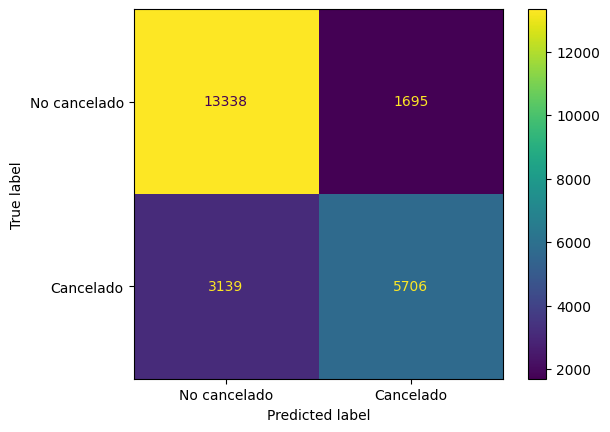

In [ ]:
# Mostrar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No cancelado', 'Cancelado'])
disp.plot(cmap='Blues')
plt.show()

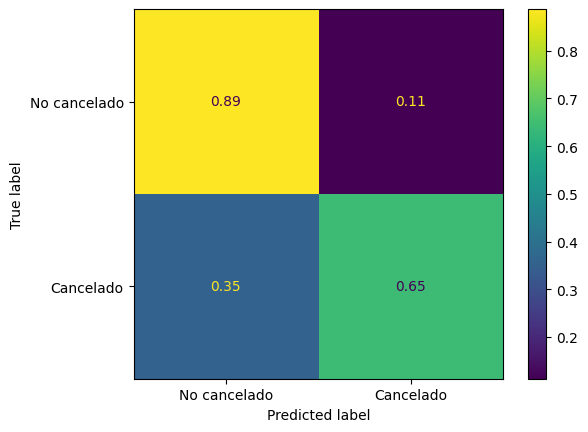

In [ ]:
# Mostrar la matriz de confusión normalizada
cm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No cancelado', 'Cancelado'])
disp.plot(cmap='Blues', values_format='.2%')
plt.show()

# Modelo Random Forest
---

In [ ]:
%%time

# Entrenamiento de un modelo de RandomForest Classifier
modelo_rfc = RandomForestClassifier(n_estimators=150, max_depth=3, random_state=42, n_jobs=num_jobs)
modelo_rfc.fit(X_train, y_train)

CPU times: total: 3.98 s
Wall time: 636 ms


RandomForestClassifier(max_depth=3, n_estimators=150, n_jobs=-1,
                       random_state=42)

In [ ]:
# Hacemos predicciones sobre el conjunto de test
y_pred = modelo_rfc.predict(X_test)

# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Cálculo del AUC (Area Under the Curve)
y_proba = modelo_rfc.predict_proba(X_test)[:, cancelado_idx]
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {acc:.2f}")
print(f"Precisión: {prec:.2f}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

Accuracy:  0.76
Precisión: 0.99
Recall:    0.35
F1-Score:  0.52
AUC:       0.82



In [ ]:
# Reporte detallado de las métricas de evaluación
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.72      1.00      0.84     15033
           1       0.99      0.35      0.52      8845

    accuracy                           0.76     23878
   macro avg       0.86      0.68      0.68     23878
weighted avg       0.82      0.76      0.72     23878



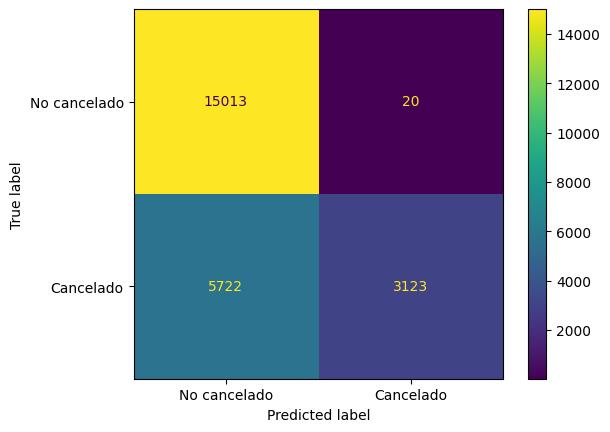

In [ ]:
# Mostrar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No cancelado', 'Cancelado'])
disp.plot(cmap='Blues')
plt.show()

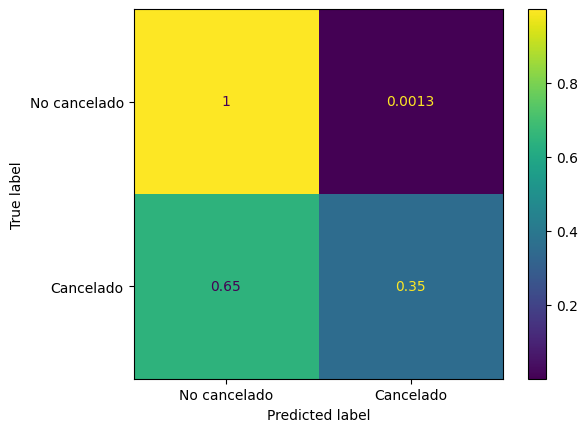

In [ ]:
# Mostrar la matriz de confusión normalizada
cm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No cancelado', 'Cancelado'])
disp.plot(cmap='Blues', values_format='.2%')
plt.show()

### Random Forest con GridSearch

In [ ]:
%%time

# Entrenamos un modelo usando GridSearchCV para encontrar los mejores hiperparámetros
dict_parametros = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

modelo_rfc = RandomForestClassifier(random_state=42, n_jobs=num_jobs)
modelo_rfc_cv = GridSearchCV(modelo_rfc, dict_parametros, cv=5, scoring='accuracy')
modelo_rfc_cv.fit(X_train, y_train)

CPU times: total: 29min 3s
Wall time: 2min 28s


GridSearchCV(cv=5, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             param_grid={'max_depth': [None, 5, 10], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy')

In [ ]:
# Visualizar los mejores hiperparámetros encontrados
print(f"Mejores hiperparámetros encontrados: {modelo_rfc_cv.best_params_}")
print(f"Mejor score obtenido: {modelo_rfc_cv.best_score_:.2%}")

Mejores hiperparámetros encontrados: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Mejor score obtenido: 82.42%


In [ ]:
%%time

# Entrenamos el modelo con los mejores hiperparámetros encontrados
modelo_rfc = RandomForestClassifier(
    n_estimators=modelo_rfc_cv.best_params_['n_estimators'],
    max_depth=modelo_rfc_cv.best_params_['max_depth'],
    min_samples_leaf=modelo_rfc_cv.best_params_['min_samples_leaf'],
    min_samples_split=modelo_rfc_cv.best_params_['min_samples_split'],
    random_state=42,
    n_jobs=num_jobs
)
modelo_rfc.fit(X_train, y_train)

CPU times: total: 44 s
Wall time: 2.96 s


RandomForestClassifier(min_samples_split=5, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [ ]:
# Hacemos predicciones sobre el conjunto de test
y_pred = modelo_rfc.predict(X_test)

# Obtenemos las probabilidades de pertenencia a la clase positiva (1)
# En este caso, la clase positiva es 'Cancelado'
y_proba = modelo_rfc.predict_proba(X_test)[:, cancelado_idx]

# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Cálculo del AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {acc:.2f}")
print(f"Precisión: {prec:.2f}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

Accuracy:  0.83
Precisión: 0.81
Recall:    0.70
F1-Score:  0.75
AUC:       0.90



In [ ]:
# Reporte detallado de las métricas de evaluación
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87     15033
           1       0.81      0.70      0.75      8845

    accuracy                           0.83     23878
   macro avg       0.82      0.80      0.81     23878
weighted avg       0.83      0.83      0.82     23878



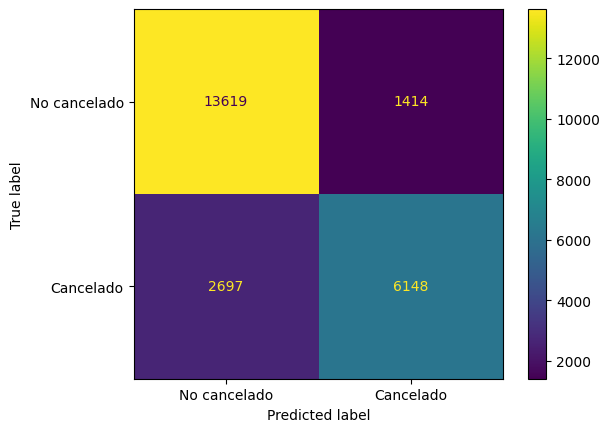

In [ ]:
# Mostrar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No cancelado', 'Cancelado'])
disp.plot(cmap='Blues')
plt.show()

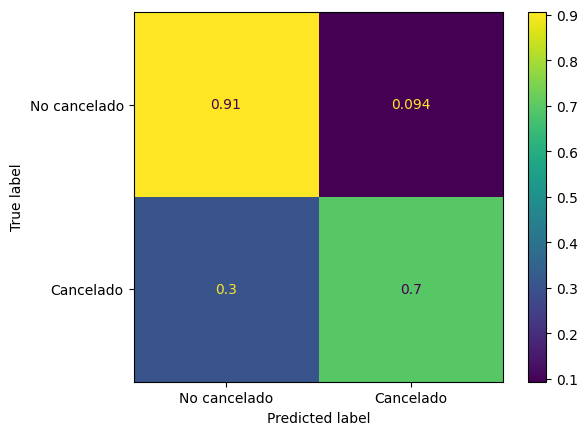

In [ ]:
# Mostrar la matriz de confusión normalizada
cm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No cancelado', 'Cancelado'])
disp.plot(cmap='Blues', values_format='.2%')
plt.show()

# Modelo Gradient Boosting - LightGBM
---

In [ ]:
%%time

# Entrenamiento de un modelo de LGBM Classifier
modelo_lgbm = LGBMClassifier(random_state=42, n_jobs=num_jobs)
modelo_lgbm.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 35379, number of negative: 60133
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011948 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1181
[LightGBM] [Info] Number of data points in the train set: 95512, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.370414 -> initscore=-0.530440
[LightGBM] [Info] Start training from score -0.530440
CPU times: total: 9.84 s
Wall time: 654 ms


LGBMClassifier(n_jobs=-1, random_state=42)

In [ ]:
# Hacemos predicciones sobre el conjunto de test
y_pred = modelo_lgbm.predict(X_test)

# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Cálculo del AUC (Area Under the Curve)
y_proba = modelo_lgbm.predict_proba(X_test)[:, cancelado_idx]
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {acc:.2f}")
print(f"Precisión: {prec:.2f}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

Accuracy:  0.80
Precisión: 0.82
Recall:    0.60
F1-Score:  0.69
AUC:       0.88



In [ ]:
# Reporte detallado de las métricas de evaluación
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.80      0.92      0.85     15033
           1       0.82      0.60      0.69      8845

    accuracy                           0.80     23878
   macro avg       0.81      0.76      0.77     23878
weighted avg       0.81      0.80      0.80     23878



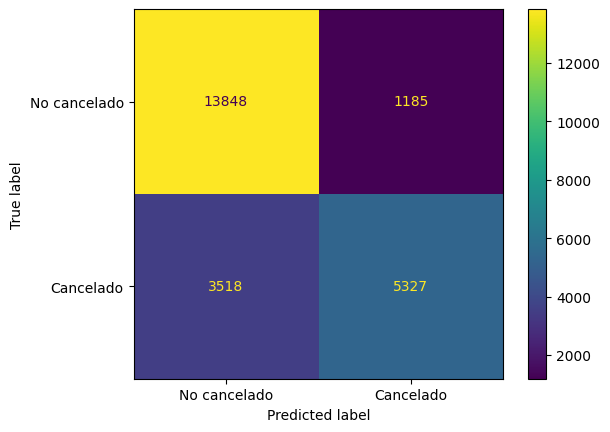

In [ ]:
# Mostrar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No cancelado', 'Cancelado'])
disp.plot(cmap='Blues')
plt.show()

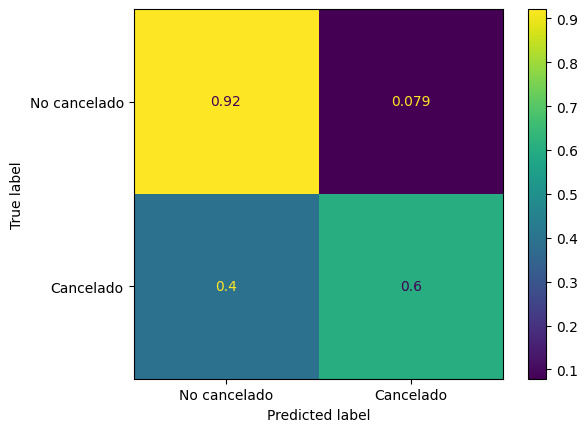

In [ ]:
# Mostrar la matriz de confusión normalizada
cm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No cancelado', 'Cancelado'])
disp.plot(cmap='Blues', values_format='.2%')
plt.show()

### LightGBM con GridSearch

In [ ]:
%%time

# Entrenamos un modelo usando GridSearchCV para encontrar los mejores hiperparámetros
dict_parametros = {
    'n_estimators': [100, 200],
    'learning_rate': [0.03, 0.1],
    'max_depth': [6, 10],
    'num_leaves': [31, 63]
}

modelo_lgbm = LGBMClassifier(random_state=42, n_jobs=num_jobs)
modelo_lgbm_cv = GridSearchCV(modelo_lgbm, dict_parametros, cv=5, scoring='accuracy')
modelo_lgbm_cv.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 28303, number of negative: 48106
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005825 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1168
[LightGBM] [Info] Number of data points in the train set: 76409, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.370414 -> initscore=-0.530439
[LightGBM] [Info] Start training from score -0.530439
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 28303, number of negative: 48106
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007062 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_c

GridSearchCV(cv=5, estimator=LGBMClassifier(n_jobs=-1, random_state=42),
             param_grid={'learning_rate': [0.03, 0.1], 'max_depth': [6, 10],
                         'n_estimators': [100, 200], 'num_leaves': [31, 63]},
             scoring='accuracy')

In [ ]:
# Visualizar los mejores hiperparámetros encontrados
print(f"Mejores hiperparámetros encontrados: {modelo_lgbm_cv.best_params_}")
print(f"Mejor score obtenido: {modelo_lgbm_cv.best_score_:.2%}")

Mejores hiperparámetros encontrados: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 200, 'num_leaves': 63}
Mejor score obtenido: 81.27%


In [ ]:
%%time

# Entrenamos el modelo con los mejores hiperparámetros encontrados
modelo_lgbm = LGBMClassifier(
    learning_rate=modelo_lgbm_cv.best_params_['learning_rate'],
    max_depth=modelo_lgbm_cv.best_params_['max_depth'],
    n_estimators=modelo_lgbm_cv.best_params_['n_estimators'],
    num_leaves=modelo_lgbm_cv.best_params_['num_leaves'],
    random_state=42,
    n_jobs=num_jobs
)
modelo_lgbm.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 35379, number of negative: 60133
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006913 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1181
[LightGBM] [Info] Number of data points in the train set: 95512, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.370414 -> initscore=-0.530440
[LightGBM] [Info] Start training from score -0.530440
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

LGBMClassifier(max_depth=10, n_estimators=200, n_jobs=-1, num_leaves=63,
               random_state=42)

In [ ]:
# Hacemos predicciones sobre el conjunto de test
y_pred = modelo_lgbm.predict(X_test)

# Obtenemos las probabilidades de pertenencia a la clase positiva (1)
# En este caso, la clase positiva es 'Cancelado'
y_proba = modelo_lgbm.predict_proba(X_test)[:, cancelado_idx]

# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Cálculo del AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {acc:.2f}")
print(f"Precisión: {prec:.2f}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

Accuracy:  0.81
Precisión: 0.82
Recall:    0.64
F1-Score:  0.72
AUC:       0.89



In [ ]:
# Reporte detallado de las métricas de evaluación
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.81      0.92      0.86     15033
           1       0.82      0.64      0.72      8845

    accuracy                           0.81     23878
   macro avg       0.82      0.78      0.79     23878
weighted avg       0.81      0.81      0.81     23878



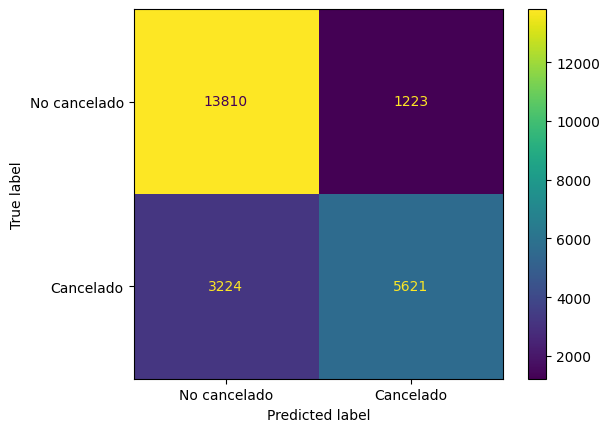

In [ ]:
# Mostrar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No cancelado', 'Cancelado'])
disp.plot(cmap='Blues')
plt.show()

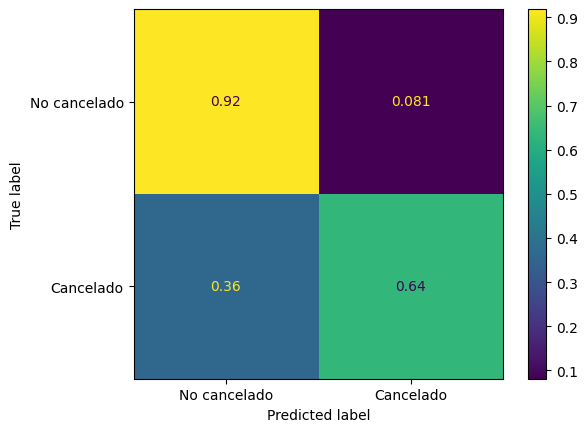

In [ ]:
# Mostrar la matriz de confusión normalizada
cm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No cancelado', 'Cancelado'])
disp.plot(cmap='Blues', values_format='.2%')
plt.show()

# Red neuronal multicapa usando Keras de TensorFlow
---

In [70]:
# Definir la arquitectura del modelo
modelo_keras = models.Sequential([
    layers.Input(shape=(X.shape[1], ), name='i1'),
    layers.Dense(128, activation='relu', name='h1'),
    layers.Dense(64, activation='relu', name='h2'),
    layers.Dense(32, activation='relu', name='h3'),
    layers.Dense(1, activation='sigmoid', name='o1')
])

# Compilar el modelo
optimizer_adam = tf.keras.optimizers.Adam(learning_rate=0.001)
modelo_keras.compile(optimizer=optimizer_adam, loss='binary_crossentropy', metrics=['accuracy'])

# Mostrar un resumen del modelo
modelo_keras.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ h1 (Dense)                      │ (None, 128)            │         5,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h2 (Dense)                      │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h3 (Dense)                      │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ o1 (Dense)                      │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,257 (63.50 KB)

 Trainable params: 16,257 (63.50 KB)

 Non-trainable params: 0 (0.00 B)

In [71]:
%%time

# Entrenamos el modelo y guardamos el historial para visualizar el aprendizaje
history_keras = modelo_keras.fit(X_train, y_train, epochs=200, validation_split=0.2, verbose=1)

Epoch 1/200
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7674 - loss: 0.4762 - val_accuracy: 0.7788 - val_loss: 0.4439
Epoch 2/200
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7867 - loss: 0.4316 - val_accuracy: 0.7820 - val_loss: 0.4406
Epoch 3/200
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7877 - loss: 0.4292 - val_accuracy: 0.7819 - val_loss: 0.4363
Epoch 4/200
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7874 - loss: 0.4238 - val_accuracy: 0.7836 - val_loss: 0.4314
Epoch 5/200
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7895 - loss: 0.4183 - val_accuracy: 0.7829 - val_loss: 0.4294
Epoch 6/200
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7910 - loss: 0.4147 - val_accuracy: 0.7858 - val_loss: 0.4329
Epoch 7/200
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7910 - loss: 0.4164 - val_accuracy: 0.7883 - val_loss: 0.4256
Epoch 8/200
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7946 - loss: 0

In [72]:
# Evaluamos el modelo en el conjunto de prueba
loss_keras, accuracy_keras = modelo_keras.evaluate(X_test, y_test)
print(f"Test Loss: {loss_keras:.4f}, Test Accuracy: {accuracy_keras:.4f}")

747/747 ━━━━━━━━━━━━━━━━━━━━ 1s 744us/step - accuracy: 0.7860 - loss: 0.6071
Test Loss: 0.6037, Test Accuracy: 0.7876


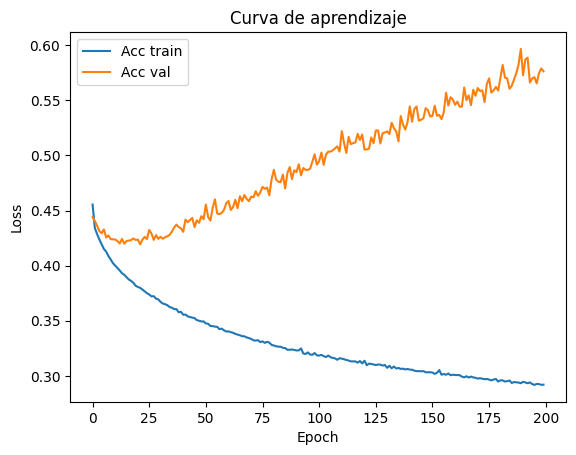

In [73]:
# Se muestra la función de coste del modelo
plt.plot(history_keras.history['loss'], label='Acc train')
plt.plot(history_keras.history['val_loss'], label='Acc val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Curva de aprendizaje')
plt.legend()
plt.show()

In [74]:
# Hacer predicciones y convertir probabilidades a 0/1
y_pred_prob = modelo_keras.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

747/747 ━━━━━━━━━━━━━━━━━━━━ 0s 474us/step


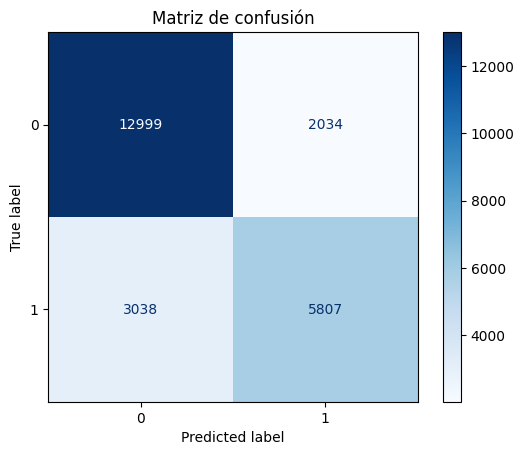

In [75]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Matriz de confusión')
plt.show()

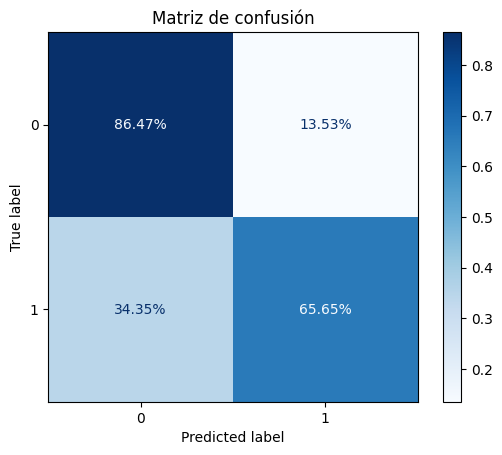

In [76]:
# Matriz de confusión normalizada
cm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='.2%')
plt.title('Matriz de confusión')
plt.show()

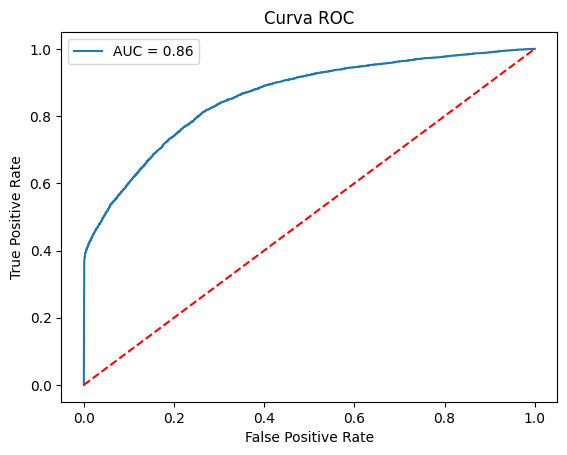

In [77]:
# Obtenemos la curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label='AUC = {:.2f}'.format(roc_auc))
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.show()

In [82]:
print(f"ROC-AUC: {roc_auc:.5f}")

ROC-AUC: 0.85857


# Consideraciones finales

## Rendimiento

- Usar RandomizedSearchCV en lugar de GridSearchCV para mejorar el rendimiento de la búsqueda de mejores hiperparámetros.